In [4]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
targets = fashion_mnist.target.astype(int)

In [5]:
targets

array([9, 0, 0, ..., 8, 1, 5], shape=(70000,))

In [7]:
X_train, y_train = fashion_mnist.data[:60000], targets[:60000]
X_test, y_test = fashion_mnist.data[60000:], targets[60000:]

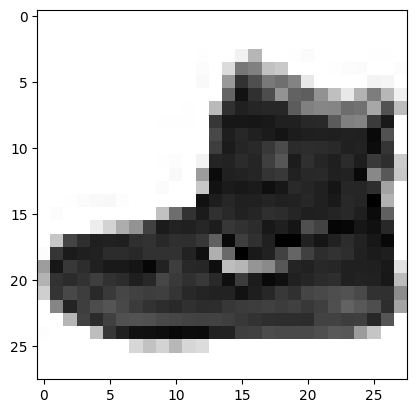

In [19]:
import matplotlib.pyplot as plt

X_sample = X_train[0].reshape(28, 28)
plt.imshow(X_sample, cmap='binary')
plt.show()

In [20]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [21]:
class_names[y_train[0]]

'Ankle boot'

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True,
                        early_stopping=True, random_state=123)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

Iteration 1, loss = 0.55041335
Validation score: 0.848000
Iteration 2, loss = 0.38580580
Validation score: 0.867000
Iteration 3, loss = 0.34462366
Validation score: 0.873833
Iteration 4, loss = 0.31197322
Validation score: 0.880333
Iteration 5, loss = 0.29517722
Validation score: 0.886833
Iteration 6, loss = 0.28100921
Validation score: 0.880500
Iteration 7, loss = 0.26809539
Validation score: 0.888000
Iteration 8, loss = 0.25443960
Validation score: 0.891667
Iteration 9, loss = 0.24308993
Validation score: 0.883167
Iteration 10, loss = 0.23537969
Validation score: 0.893167
Iteration 11, loss = 0.22324568
Validation score: 0.898167
Iteration 12, loss = 0.21626196
Validation score: 0.889000
Iteration 13, loss = 0.20801228
Validation score: 0.892667
Iteration 14, loss = 0.20109449
Validation score: 0.892500
Iteration 15, loss = 0.19215180
Validation score: 0.895500
Iteration 16, loss = 0.18439316
Validation score: 0.897167
Iteration 17, loss = 0.17899926
Validation score: 0.889000
Iterat

In [23]:
X_new = X_test[:15]
mlp_clf.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4])

In [27]:
y_proba = mlp_clf.predict_proba(X_new)
y_proba[12].round(1)

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])